**Final evaluation setup**

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FINAL_MODEL_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "stacked_lstm"
    / "stacked_lstm_32_32_20_epochs.keras"
)

FINAL_CONFIG_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "stacked_lstm"
    / "final_config.json"
)

print("Project root:")
print(PROJECT_ROOT)

print("\nModel:")
print(FINAL_MODEL_PATH)

print("\nConfig:")
print(FINAL_CONFIG_PATH)

Project root:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction

Model:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\stacked_lstm\stacked_lstm_32_32_20_epochs.keras

Config:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\stacked_lstm\final_config.json


**Load final configuration**

In [2]:
with open(
    FINAL_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    final_config = json.load(file)

print(
    json.dumps(
        final_config,
        indent=4,
    )
)

{
    "dataset": "Sleep-EDF Expanded",
    "subjects": 197,
    "eeg_channel": "EEG Fpz-Cz",
    "sampling_frequency_hz": 100.0,
    "features": [
        "delta_absolute",
        "theta_absolute",
        "alpha_absolute",
        "beta_absolute",
        "delta_relative",
        "theta_relative",
        "alpha_relative",
        "beta_relative",
        "spectral_entropy",
        "dominant_frequency"
    ],
    "sequence_length_epochs": 20,
    "epoch_duration_seconds": 30,
    "temporal_context_minutes": 10,
    "model": "stacked_lstm",
    "lstm_units": [
        32,
        32
    ],
    "dropout": 0.3,
    "loss": "unweighted_sparse_categorical_crossentropy",
    "optimizer": "Adam",
    "initial_learning_rate": 0.001,
    "batch_size": 256,
    "classes": [
        "W",
        "N1",
        "N2",
        "N3",
        "REM"
    ],
    "random_seed": 42
}


**Load frozen final model**

In [3]:
final_model = tf.keras.models.load_model(
    FINAL_MODEL_PATH
)

final_model.summary()

Model: "stacked_sleep_stage_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_features (InputLayer)       │ (None, 20, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 32)         │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sleep_stage (Dense)             │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,969 (163.95 KB)

 Trainable params: 13,989 (54.64 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 27,980 (109.30 KB)

**Load final feature dataset**

In [4]:
from src.preprocessing.normalization import (
    SleepFeatureScaler,
)

from src.preprocessing.sequences import (
    build_sequences_from_dataframe,
    encode_sleep_stage_labels,
)

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "sleep_edf_features.csv"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "subject_split.csv"
)

df = pd.read_csv(
    FEATURES_PATH
)

split_df = pd.read_csv(
    SPLIT_PATH
)

df = df.merge(
    split_df,
    on="subject_id",
    how="inner",
    validate="many_to_one",
)

train_df = (
    df[
        df["split"] == "train"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

val_df = (
    df[
        df["split"] == "val"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

test_df = (
    df[
        df["split"] == "test"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

print(
    "Train:",
    train_df.shape,
)

print(
    "Validation:",
    val_df.shape,
)

print(
    "Test:",
    test_df.shape,
)

Train: (319628, 17)
Validation: (69602, 17)
Test: (68347, 17)


**Recreate final normalization**

In [5]:
feature_scaler = SleepFeatureScaler()

X_train_scaled = (
    feature_scaler.fit_transform(
        train_df
    )
)

X_val_scaled = (
    feature_scaler.transform(
        val_df
    )
)

X_test_scaled = (
    feature_scaler.transform(
        test_df
    )
)

print(
    "Train scaled:",
    X_train_scaled.shape,
)

print(
    "Validation scaled:",
    X_val_scaled.shape,
)

print(
    "Test scaled:",
    X_test_scaled.shape,
)

Train scaled: (319628, 10)
Validation scaled: (69602, 10)
Test scaled: (68347, 10)


**Build final 20-epoch test sequences**

In [6]:
X_test_final, y_test_final_labels = (
    build_sequences_from_dataframe(
        dataframe=test_df,
        feature_values=X_test_scaled,
        sequence_length=20,
    )
)

y_test_final = (
    encode_sleep_stage_labels(
        y_test_final_labels
    )
)

print(
    "Final test sequences:",
    X_test_final.shape,
)

print(
    "Final test labels:",
    y_test_final.shape,
)

Final test sequences: (67017, 20, 10)
Final test labels: (67017,)


**Generate final predictions**

In [7]:
test_probabilities = (
    final_model.predict(
        X_test_final,
        batch_size=256,
        verbose=1,
    )
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1,
)

print(
    "Probability shape:",
    test_probabilities.shape,
)

print(
    "Prediction shape:",
    test_predictions.shape,
)

print(
    "Label shape:",
    y_test_final.shape,
)

262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Probability shape: (67017, 5)
Prediction shape: (67017,)
Label shape: (67017,)


**Final classification report**

In [8]:
CLASS_NAMES = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

final_report = classification_report(
    y_test_final,
    test_predictions,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
)

print(final_report)

              precision    recall  f1-score   support

           W     0.9608    0.9615    0.9612     43009
          N1     0.4333    0.3383    0.3800      2891
          N2     0.7667    0.7907    0.7785     13160
          N3     0.8421    0.6480    0.7324      2855
         REM     0.6695    0.7809    0.7209      5102

    accuracy                         0.8740     67017
   macro avg     0.7345    0.7039    0.7146     67017
weighted avg     0.8727    0.8740    0.8722     67017



**Final evaluation metrics**

In [9]:
final_metrics = {
    "accuracy": accuracy_score(
        y_test_final,
        test_predictions,
    ),

    "balanced_accuracy": (
        balanced_accuracy_score(
            y_test_final,
            test_predictions,
        )
    ),

    "macro_precision": (
        precision_score(
            y_test_final,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),

    "macro_recall": (
        recall_score(
            y_test_final,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),

    "macro_f1": (
        f1_score(
            y_test_final,
            test_predictions,
            average="macro",
            zero_division=0,
        )
    ),

    "weighted_f1": (
        f1_score(
            y_test_final,
            test_predictions,
            average="weighted",
            zero_division=0,
        )
    ),
}

final_metrics_df = pd.DataFrame(
    [final_metrics]
)

display(
    final_metrics_df.round(4)
)

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,0.874,0.7039,0.7345,0.7039,0.7146,0.8722


**Final confusion matrix**

Final confusion matrix:
[[41353   418  1037    43   158]
 [  728   978   721     2   462]
 [  586   552 10405   302  1315]
 [   64     6   903  1850    32]
 [  309   303   506     0  3984]]


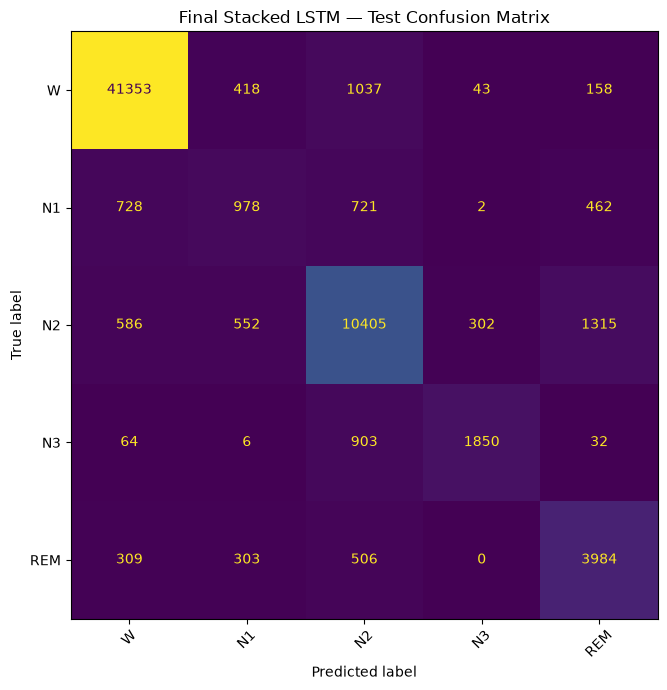

In [10]:
final_cm = confusion_matrix(
    y_test_final,
    test_predictions,
)

print(
    "Final confusion matrix:"
)

print(
    final_cm
)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=CLASS_NAMES,
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

cm_display.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45,
    colorbar=False,
)

ax.set_title(
    "Final Stacked LSTM — Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

**Normalized confusion matrix**

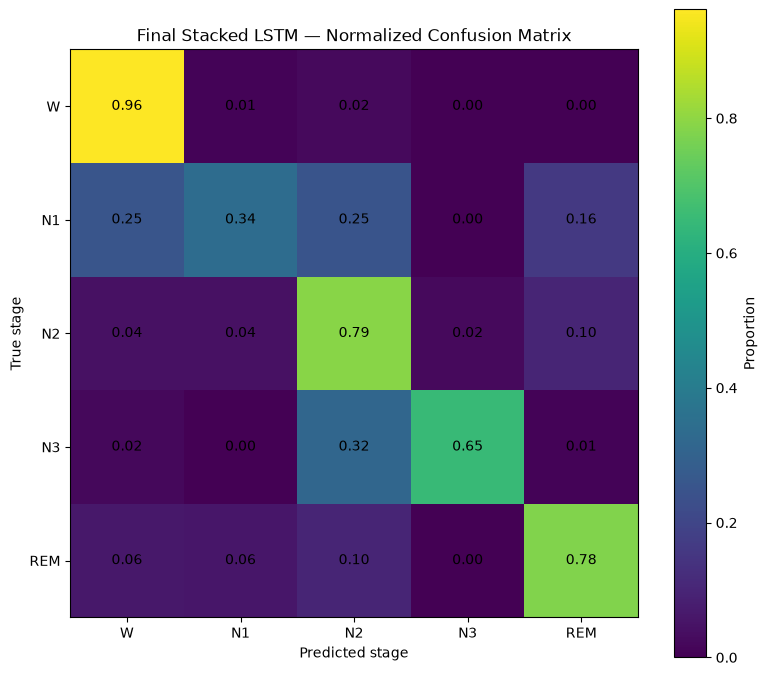

In [11]:
final_cm_normalized = (
    final_cm
    / final_cm.sum(
        axis=1,
        keepdims=True,
    )
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

im = ax.imshow(
    final_cm_normalized
)

ax.set_xticks(
    np.arange(len(CLASS_NAMES))
)

ax.set_yticks(
    np.arange(len(CLASS_NAMES))
)

ax.set_xticklabels(
    CLASS_NAMES
)

ax.set_yticklabels(
    CLASS_NAMES
)

ax.set_xlabel(
    "Predicted stage"
)

ax.set_ylabel(
    "True stage"
)

ax.set_title(
    "Final Stacked LSTM — Normalized Confusion Matrix"
)

for i in range(
    len(CLASS_NAMES)
):
    for j in range(
        len(CLASS_NAMES)
    ):
        ax.text(
            j,
            i,
            f"{final_cm_normalized[i, j]:.2f}",
            ha="center",
            va="center",
        )

plt.colorbar(
    im,
    ax=ax,
    label="Proportion",
)

plt.tight_layout()
plt.show()

**Save final evaluation artifacts**

In [12]:
FINAL_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "final_evaluation"
)

FINAL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

final_metrics_df.to_csv(
    FINAL_RESULTS_DIR
    / "final_metrics.csv",
    index=False,
)

pd.DataFrame(
    final_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
).to_csv(
    FINAL_RESULTS_DIR
    / "final_confusion_matrix.csv"
)

print(
    "Final evaluation results saved to:"
)

print(
    FINAL_RESULTS_DIR
)

Final evaluation results saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\results\final_evaluation


**Save per-class metrics**

In [13]:
final_report_dict = classification_report(
    y_test_final,
    test_predictions,
    target_names=CLASS_NAMES,
    digits=6,
    zero_division=0,
    output_dict=True,
)

final_per_class_df = (
    pd.DataFrame(
        final_report_dict
    ).T
)

final_per_class_df.to_csv(
    FINAL_RESULTS_DIR
    / "final_classification_report.csv"
)

display(
    final_per_class_df.round(4)
)

,precision,recall,f1-score,support
W,0.9608,0.9615,0.9612,43009.000
N1,0.4333,0.3383,0.3800,2891.000
N2,0.7667,0.7907,0.7785,13160.000
N3,0.8421,0.6480,0.7324,2855.000
REM,0.6695,0.7809,0.7209,5102.000
accuracy,0.8740,0.8740,0.8740,0.874
macro avg,0.7345,0.7039,0.7146,67017.000
weighted avg,0.8727,0.8740,0.8722,67017.000


**Save final predictions**

In [14]:
final_prediction_df = pd.DataFrame(
    {
        "true_stage": [
            CLASS_NAMES[i]
            for i in y_test_final
        ],

        "predicted_stage": [
            CLASS_NAMES[i]
            for i in test_predictions
        ],

        "prob_W": test_probabilities[:, 0],
        "prob_N1": test_probabilities[:, 1],
        "prob_N2": test_probabilities[:, 2],
        "prob_N3": test_probabilities[:, 3],
        "prob_REM": test_probabilities[:, 4],
    }
)

final_prediction_df.to_csv(
    FINAL_RESULTS_DIR
    / "final_predictions.csv",
    index=False,
)

print(
    "Saved:",
    FINAL_RESULTS_DIR
    / "final_predictions.csv"
)

Saved: D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\results\final_evaluation\final_predictions.csv


**Final experiment summary**

In [15]:
experiment_summary = pd.DataFrame(
    [
        {
            "experiment": "Weighted loss",
            "accuracy": 0.7762,
            "balanced_accuracy": 0.7454,
            "macro_f1": 0.6431,
            "weighted_f1": 0.8006,
        },
        {
            "experiment": "Moderated weighting",
            "accuracy": 0.7983,
            "balanced_accuracy": 0.7111,
            "macro_f1": 0.6554,
            "weighted_f1": 0.8146,
        },
        {
            "experiment": "Unweighted loss",
            "accuracy": 0.8589,
            "balanced_accuracy": 0.7046,
            "macro_f1": 0.7024,
            "weighted_f1": 0.8601,
        },
        {
            "experiment": "5 epochs",
            "accuracy": 0.8387,
            "balanced_accuracy": 0.6800,
            "macro_f1": 0.6746,
            "weighted_f1": 0.8403,
        },
        {
            "experiment": "10 epochs",
            "accuracy": 0.8410,
            "balanced_accuracy": 0.6821,
            "macro_f1": 0.6795,
            "weighted_f1": 0.8442,
        },
        {
            "experiment": "20 epochs",
            "accuracy": 0.8602,
            "balanced_accuracy": 0.6985,
            "macro_f1": 0.7017,
            "weighted_f1": 0.8614,
        },
        {
            "experiment": "LSTM(32)",
            "accuracy": 0.8662,
            "balanced_accuracy": 0.7004,
            "macro_f1": 0.7081,
            "weighted_f1": 0.8670,
        },
        {
            "experiment": "LSTM(64)",
            "accuracy": 0.8602,
            "balanced_accuracy": 0.6985,
            "macro_f1": 0.7017,
            "weighted_f1": 0.8614,
        },
        {
            "experiment": "LSTM(128)",
            "accuracy": 0.8332,
            "balanced_accuracy": 0.6656,
            "macro_f1": 0.6546,
            "weighted_f1": 0.8413,
        },
        {
            "experiment": "Stacked LSTM(32+32)",
            "accuracy": 0.8740,
            "balanced_accuracy": 0.7039,
            "macro_f1": 0.7146,
            "weighted_f1": 0.8722,
        },
        {
            "experiment": "Bidirectional LSTM",
            "accuracy": 0.8651,
            "balanced_accuracy": 0.7067,
            "macro_f1": 0.7070,
            "weighted_f1": 0.8671,
        },
        {
            "experiment": "Attention LSTM",
            "accuracy": 0.8452,
            "balanced_accuracy": 0.6817,
            "macro_f1": 0.6733,
            "weighted_f1": 0.8506,
        },
    ]
)

display(
    experiment_summary.round(4)
)

,experiment,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Weighted loss,0.7762,0.7454,0.6431,0.8006
1,Moderated weighting,0.7983,0.7111,0.6554,0.8146
2,Unweighted loss,0.8589,0.7046,0.7024,0.8601
3,5 epochs,0.8387,0.6800,0.6746,0.8403
4,10 epochs,0.8410,0.6821,0.6795,0.8442
5,20 epochs,0.8602,0.6985,0.7017,0.8614
6,LSTM(32),0.8662,0.7004,0.7081,0.8670
7,LSTM(64),0.8602,0.6985,0.7017,0.8614
8,LSTM(128),0.8332,0.6656,0.6546,0.8413
9,Stacked LSTM(32+32),0.8740,0.7039,0.7146,0.8722


**Save final experiment summary**

In [16]:
experiment_summary.to_csv(
    FINAL_RESULTS_DIR
    / "experiment_summary.csv",
    index=False,
)

**Rebuild train/validation sequences**

In [17]:
X_train_20_final, y_train_20_labels = (
    build_sequences_from_dataframe(
        dataframe=train_df,
        feature_values=X_train_scaled,
        sequence_length=20,
    )
)

X_val_20_final, y_val_20_labels = (
    build_sequences_from_dataframe(
        dataframe=val_df,
        feature_values=X_val_scaled,
        sequence_length=20,
    )
)

y_train_20_final = encode_sleep_stage_labels(
    y_train_20_labels
)

y_val_20_final = encode_sleep_stage_labels(
    y_val_20_labels
)

print(
    "Training:",
    X_train_20_final.shape,
    y_train_20_final.shape,
)

print(
    "Validation:",
    X_val_20_final.shape,
    y_val_20_final.shape,
)

Training: (314291, 20, 10) (314291,)
Validation: (68730, 20, 10) (68730,)


**Seed reproducibility helper**

In [20]:
import random
import numpy as np
import tensorflow as tf


def set_experiment_seed(seed):
    """
    Reset Python, NumPy, and TensorFlow random states.
    """

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    print(
        f"Experiment seed set to {seed}"
    )

**Multi-seed final-model training**

In [ ]:
from src.models.lstm import (
    build_stacked_lstm,
    compile_baseline_lstm,
)
from tensorflow import keras

SEEDS = [42, 123, 456]


def train_final_model_with_seed(
    seed: int,
):
    """
    Train the frozen final architecture using one random seed.
    """

    print("=" * 70)
    print(f"FINAL MODEL — SEED {seed}")
    print("=" * 70)

    set_experiment_seed(seed)

    model = build_stacked_lstm(
        sequence_length=20,
        n_features=10,
        n_classes=5,
        lstm_units=32,
        dropout_rate=0.30,
    )

    model = compile_baseline_lstm(
        model,
        learning_rate=1e-3,
    )

    train_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_train_20_final,
                y_train_20_final,
            )
        )
        .shuffle(
            buffer_size=10000,
            seed=seed,
            reshuffle_each_iteration=True,
        )
        .batch(256)
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    val_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_val_20_final,
                y_val_20_final,
            )
        )
        .batch(256)
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=callbacks,
        shufffle=False,
        verbose=1,
    )

    return model, history

**Train final model with seed 42**

In [24]:
model_seed_42, history_seed_42 = (
    train_final_model_with_seed(
        42
    )
)

FINAL MODEL — SEED 42
Experiment seed set to 42
Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1228/1228 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.8338 - loss: 0.4529 - val_accuracy: 0.7311 - val_loss: 0.7183 - learning_rate: 0.0010
Epoch 2/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.8722 - loss: 0.3499 - val_accuracy: 0.7670 - val_loss: 0.6671 - learning_rate: 0.0010
Epoch 3/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.8826 - loss: 0.3209 - val_accuracy: 0.7736 - val_loss: 0.6648 - learning_rate: 0.0010
Epoch 4/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - accuracy: 0.8888 - loss: 0.3026 - val_accuracy: 0.7877 - val_loss: 0.6308 - learning_rate: 0.0010
Epoch 5/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.8937 - loss: 0.2882 - val_accuracy: 0.7874 - val_loss: 0.6458 - learning_rate: 0.0010
Epoch 6/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - accuracy: 0.8957 - loss: 0.2826 - val_accuracy: 0.7938 - val_loss: 0.6268 - learning_rate: 0.0010
Epoch 7/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.8981 

**Train final model with seed 123**

In [25]:
model_seed_123, history_seed_123 = (
    train_final_model_with_seed(
        123
    )
)

FINAL MODEL — SEED 123
Experiment seed set to 123
Epoch 1/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - accuracy: 0.8383 - loss: 0.4455 - val_accuracy: 0.7450 - val_loss: 0.7146 - learning_rate: 0.0010
Epoch 2/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.8735 - loss: 0.3456 - val_accuracy: 0.7682 - val_loss: 0.6815 - learning_rate: 0.0010
Epoch 3/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.8826 - loss: 0.3208 - val_accuracy: 0.7757 - val_loss: 0.6495 - learning_rate: 0.0010
Epoch 4/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.8880 - loss: 0.3043 - val_accuracy: 0.7963 - val_loss: 0.5945 - learning_rate: 0.0010
Epoch 5/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.8921 - loss: 0.2932 - val_accuracy: 0.8042 - val_loss: 0.5785 - learning_rate: 0.0010
Epoch 6/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.8949 - loss: 0.2833 - val_accuracy: 0.8208 - val_loss: 0.5385 - learning_rate: 0.0010
Epoch 7/30
122

**Train final model with seed 456**

In [26]:
model_seed_456, history_seed_456 = (
    train_final_model_with_seed(
        456
    )
)

FINAL MODEL — SEED 456
Experiment seed set to 456
Epoch 1/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.8402 - loss: 0.4417 - val_accuracy: 0.7391 - val_loss: 0.7204 - learning_rate: 0.0010
Epoch 2/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.8761 - loss: 0.3401 - val_accuracy: 0.7630 - val_loss: 0.6963 - learning_rate: 0.0010
Epoch 3/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.8849 - loss: 0.3134 - val_accuracy: 0.7731 - val_loss: 0.7056 - learning_rate: 0.0010
Epoch 4/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.8887 - loss: 0.3017 - val_accuracy: 0.7997 - val_loss: 0.5855 - learning_rate: 0.0010
Epoch 5/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 35s 29ms/step - accuracy: 0.8938 - loss: 0.2874 - val_accuracy: 0.7959 - val_loss: 0.6145 - learning_rate: 0.0010
Epoch 6/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.8961 - loss: 0.2806 - val_accuracy: 0.8087 - val_loss: 0.5512 - learning_rate: 0.0010
Epoch 7/30
122

**Evaluate all final-model seeds**

In [27]:
seed_models = {
    42: model_seed_42,
    123: model_seed_123,
    456: model_seed_456,
}

seed_results = []

for seed, model in seed_models.items():

    print("=" * 70)
    print(f"Evaluating seed {seed}")
    print("=" * 70)

    probabilities = model.predict(
        X_test_final,
        batch_size=256,
        verbose=1,
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    seed_result = {
        "seed": seed,
        "accuracy": accuracy_score(
            y_test_final,
            predictions,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_test_final,
                predictions,
            )
        ),
        "macro_precision": (
            precision_score(
                y_test_final,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "macro_recall": (
            recall_score(
                y_test_final,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "macro_f1": (
            f1_score(
                y_test_final,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "weighted_f1": (
            f1_score(
                y_test_final,
                predictions,
                average="weighted",
                zero_division=0,
            )
        ),
    }

    seed_results.append(
        seed_result
    )

seed_results_df = pd.DataFrame(
    seed_results
)

display(
    seed_results_df.round(4)
)

Evaluating seed 42
262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
Evaluating seed 123
262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Evaluating seed 456
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


,seed,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,42,0.8740,0.7039,0.7345,0.7039,0.7146,0.8722
1,123,0.8695,0.7079,0.7232,0.7079,0.7111,0.8700
2,456,0.8662,0.7013,0.7243,0.7013,0.7081,0.8661


**Multi-seed mean ± standard deviation**

In [28]:
METRICS = [
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
]

seed_statistics = pd.DataFrame(
    {
        "mean": (
            seed_results_df[METRICS]
            .mean()
        ),
        "std": (
            seed_results_df[METRICS]
            .std(
                ddof=1
            )
        ),
        "min": (
            seed_results_df[METRICS]
            .min()
        ),
        "max": (
            seed_results_df[METRICS]
            .max()
        ),
    }
)

display(
    seed_statistics.round(4)
)

,mean,std,min,max
accuracy,0.8699,0.0039,0.8662,0.8740
balanced_accuracy,0.7043,0.0033,0.7013,0.7079
macro_precision,0.7273,0.0062,0.7232,0.7345
macro_recall,0.7043,0.0033,0.7013,0.7079
macro_f1,0.7113,0.0033,0.7081,0.7146
weighted_f1,0.8694,0.0031,0.8661,0.8722


**Per-class F1 across seeds**

In [29]:
per_seed_class_f1 = []

for seed, model in seed_models.items():

    probabilities = model.predict(
        X_test_final,
        batch_size=256,
        verbose=0,
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    class_f1 = f1_score(
        y_test_final,
        predictions,
        average=None,
        zero_division=0,
    )

    row = {
        "seed": seed,
    }

    for class_name, score in zip(
        CLASS_NAMES,
        class_f1,
    ):
        row[
            f"{class_name}_f1"
        ] = score

    per_seed_class_f1.append(
        row
    )

per_seed_class_f1_df = pd.DataFrame(
    per_seed_class_f1
)

display(
    per_seed_class_f1_df.round(4)
)

,seed,W_f1,N1_f1,N2_f1,N3_f1,REM_f1
0,42,0.9612,0.3800,0.7785,0.7324,0.7209
1,123,0.9603,0.3782,0.7725,0.7233,0.7214
2,456,0.9580,0.3738,0.7607,0.7294,0.7185


**Save multi-seed stability results**

In [30]:
STABILITY_DIR = (
    PROJECT_ROOT
    / "results"
    / "final_evaluation"
    / "multi_seed"
)

STABILITY_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

seed_results_df.to_csv(
    STABILITY_DIR
    / "seed_results.csv",
    index=False,
)

seed_statistics.to_csv(
    STABILITY_DIR
    / "seed_statistics.csv"
)

per_seed_class_f1_df.to_csv(
    STABILITY_DIR
    / "per_seed_class_f1.csv",
    index=False,
)

print(
    "Multi-seed results saved to:"
)

print(
    STABILITY_DIR
)

Multi-seed results saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\results\final_evaluation\multi_seed


**Final model training curves**

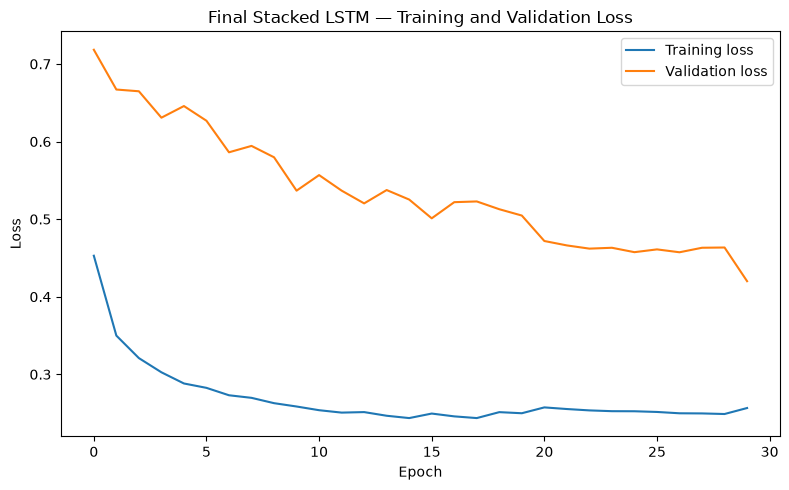

In [31]:
history_df = pd.DataFrame(
    history_seed_42.history
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    history_df["loss"],
    label="Training loss",
)

ax.plot(
    history_df["val_loss"],
    label="Validation loss",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(
    "Final Stacked LSTM — Training and Validation Loss"
)

ax.legend()

plt.tight_layout()
plt.show()

**Final model accuracy curves**

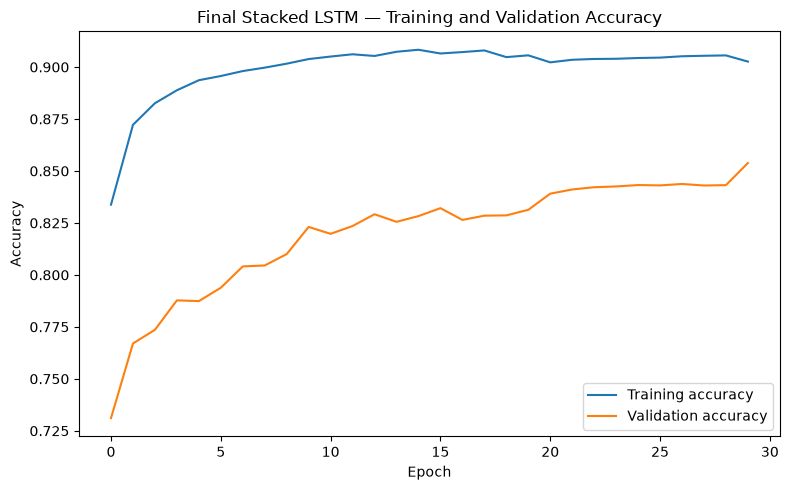

In [32]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    history_df["accuracy"],
    label="Training accuracy",
)

ax.plot(
    history_df["val_accuracy"],
    label="Validation accuracy",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title(
    "Final Stacked LSTM — Training and Validation Accuracy"
)

ax.legend()

plt.tight_layout()
plt.show()